# This notebook generates figures 3A and 3B

## Import Packages

In [1]:
import maboss # Package of the Maboss 
import ginsim # Package of the GINsim
import biolqm # Package of biolqm
import openpyxl # Package to save .xlsx files
import pandas as pd # Handle with tables
import seaborn as sns #Color tables
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings

In [2]:
warnings.simplefilter(action='ignore', category=FutureWarning)

## GINsim

### Model import

In [8]:
lrg = ginsim.load('working_data/logical_model_CSC_ewing_sarcoma.zginml')


lqm = ginsim.to_biolqm(lrg)

#Show the model
ginsim.show(lrg)

# Maboss

### Figures

In [36]:
def simulate_response_from_lqm_dn(x_node, y_node, steps=11, y_initial_prob=0):
    """
    Simulates the response of node y by varying the activation probability of node x
    using a BiolQM model converted to MaBoSS.

    Parameters:
        x_node (str): Name of the node whose activation probability will be varied.
        y_node (str): Name of the node being monitored.
        steps (int): Number of probability steps for x.
        y_initial_prob (float): Initial activation probability of the y_node.

    Returns:
        None. Displays the plot and saves the results table.
    """
    
    # Set initial state for y_node
    maboss_model.network.set_istate(y_node, [1 - y_initial_prob, y_initial_prob]) 

    # Lists to store results
    x_responses, y_responses, y_errors = [], [], []

    # Loop over x_node activation probabilities
    for prob in np.linspace(0, 1, steps):
        maboss_model.network.set_istate(x_node, [1 - prob, prob])
        simulation = maboss_model.run()

        # Get y_node probability
        y_prob = simulation.get_last_nodes_probtraj().get(y_node, [0])[0]

        # Get associated error
        y_error = simulation.get_nodes_probtraj_error().get(y_node, [0])[0]

        # Store results
        x_responses.append(prob)
        y_responses.append(y_prob)
        y_errors.append(y_error)

    # Create DataFrame with results
    results_df = pd.DataFrame({
        'x_prob': x_responses,
        'y_prob': y_responses,
        'y_error': y_errors
    })
    
    print(results_df)

    base_path = '/home/daner/Desktop/Github-ewing-stem-5-2026/working_data/'
    results_df.to_csv(f'{base_path}/dif-EWS-{y_node}_results.csv', index=False)

    # Plot results with error bars
    plt.figure(figsize=(8, 6))
    plt.errorbar(x_responses, y_responses, yerr=y_errors,
                 marker='o', capsize=5, linewidth=2, markersize=12,
                 mew=2, alpha=0.5, color='#0074ff', mec='#0074ff', mfc='#0074ff')

    plt.title(f'{y_node}', size=30)
    plt.xticks(fontsize=30)
    plt.yticks(fontsize=30)
    plt.grid(True, linestyle="-", linewidth=0.7, alpha=0.18)
   # plt.ylim(-0.05, 1) 
    plt.savefig(f'{base_path}/dif-EWS-{y_node}_results.svg', dpi=300, bbox_inches='tight', transparent=True)
    plt.show()

In [37]:
def simulate_response_from_lqm_up(x_node, y_node, steps=11, y_initial_prob=0):
    """
    Simulates the response of node y by varying the activation probability of node x
    using a BiolQM model converted to MaBoSS.

    Parameters:
        x_node (str): Name of the node whose activation probability will be varied.
        y_node (str): Name of the node being monitored.
        steps (int): Number of probability steps for x.
        y_initial_prob (float): Initial activation probability of the y_node.

    Returns:
        None. Displays the plot and saves the results table.
    """

    # Set initial state for y_node
    maboss_model.network.set_istate(y_node, [1 - y_initial_prob, y_initial_prob]) 

    # Lists to store the results
    x_responses, y_responses, y_errors = [], [], []

    # Simulate for each activation probability of x
    for prob in np.linspace(0, 1, steps):
        maboss_model.network.set_istate(x_node, [1 - prob, prob])
        simulation = maboss_model.run()
        
        # Get y_node probability and error
        y_prob = simulation.get_last_nodes_probtraj().get(y_node, [0])[0] 
        y_error = simulation.get_nodes_probtraj_error().get(y_node, [0])[0]

        x_responses.append(prob)
        y_responses.append(y_prob)
        y_errors.append(y_error)

    # Create and save results
    results_df = pd.DataFrame({
        'x_prob': x_responses,
        'y_prob': y_responses,
        'y_error': y_errors
    })
    
    print(results_df)

    base_path = '/home/daner/Desktop/Github-ewing-stem-5-2026/working_data/'
    results_df.to_csv(f'{base_path}/dif-EWS-{y_node}_results.csv', index=False)

    # Plot the results
    plt.figure(figsize=(8, 6))
    plt.errorbar(x_responses, y_responses, yerr=y_errors,
                 marker='o', capsize=5, linewidth=2, markersize=12, 
                 mew=2, alpha=0.5, color='#0074ff', mec='#0074ff', mfc='#0074ff')
    
    plt.title(f'{y_node}', size=30)
    plt.xticks(fontsize=30)
    plt.yticks(fontsize=30)
    plt.grid(True, linestyle="-", linewidth=0.7, alpha=0.18)
   # plt.ylim(-0.05, 1) 
    plt.savefig(f'{base_path}/dif-EWS-{y_node}_results.svg', dpi=300, bbox_inches='tight', transparent=True)
    plt.show()

#### Differentiated state

In [38]:
# Convert BiolQM to MaBoSS
maboss_model = biolqm.to_maboss(lqm)

In [39]:
# Set initial states (Differentiated state)
#maboss_model.network.set_istate('EWSR1_FLI1', [0, 1])
maboss_model.network.set_istate('miR_145', [0, 1])
maboss_model.network.set_istate('OCT4', [1, 0])
maboss_model.network.set_istate('SOX2', [1, 0])
maboss_model.network.set_istate('c_Myc', [1, 0])
maboss_model.network.set_istate('Let_7', [0, 1])
maboss_model.network.set_istate('STAT3', [1, 0])
maboss_model.network.set_istate('LIN28', [1, 0])
maboss_model.network.set_istate(['Stem_b1', 'Stem_b2'],  {(0,0):1, (0,1):0, (1,0):0, (1,1):0})

Warning, node Stem_b1 was previously bound to othernodes


In [40]:
# Maboss parameters
maboss_model.update_parameters(discrete_time=0, use_physrandgen=0,
        seed_pseudorandom=100, sample_count=50000,
        max_time=15, time_tick=0.5, thread_count=4,
        statdist_traj_count=100, statdist_cluster_threshold=0.9)

    x_prob   y_prob   y_error
0     0.00  0.00000  0.000000
1     0.05  0.03034  0.000071
2     0.10  0.05852  0.000101
3     0.15  0.08806  0.000136
4     0.20  0.11728  0.000149
5     0.25  0.14590  0.000166
6     0.30  0.17628  0.000187
7     0.35  0.20454  0.000211
8     0.40  0.23472  0.000230
9     0.45  0.26410  0.000240
10    0.50  0.29182  0.000257
11    0.55  0.32312  0.000267
12    0.60  0.35118  0.000281
13    0.65  0.38078  0.000291
14    0.70  0.40982  0.000298
15    0.75  0.43868  0.000312
16    0.80  0.46888  0.000321
17    0.85  0.49644  0.000328
18    0.90  0.52630  0.000338
19    0.95  0.55542  0.000346
20    1.00  0.58314  0.000364


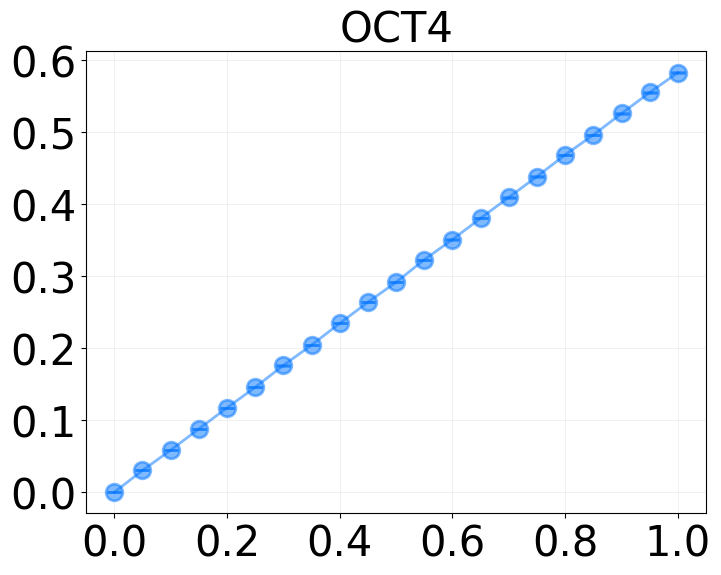

In [41]:
# OCT4
simulate_response_from_lqm_up(
    x_node="EWSR1_FLI1",  
    y_node="OCT4",  
    steps=21,        
    y_initial_prob=0  
)

    x_prob   y_prob   y_error
0     0.00  0.00000  0.000000
1     0.05  0.03034  0.000719
2     0.10  0.05852  0.001054
3     0.15  0.08806  0.001289
4     0.20  0.11728  0.001484
5     0.25  0.14590  0.001659
6     0.30  0.17628  0.001808
7     0.35  0.20454  0.001961
8     0.40  0.23472  0.002093
9     0.45  0.26410  0.002212
10    0.50  0.29182  0.002338
11    0.55  0.32312  0.002435
12    0.60  0.35118  0.002548
13    0.65  0.38078  0.002644
14    0.70  0.40982  0.002739
15    0.75  0.43868  0.002834
16    0.80  0.46888  0.002913
17    0.85  0.49644  0.002996
18    0.90  0.52630  0.003077
19    0.95  0.55542  0.003152
20    1.00  0.58314  0.003243


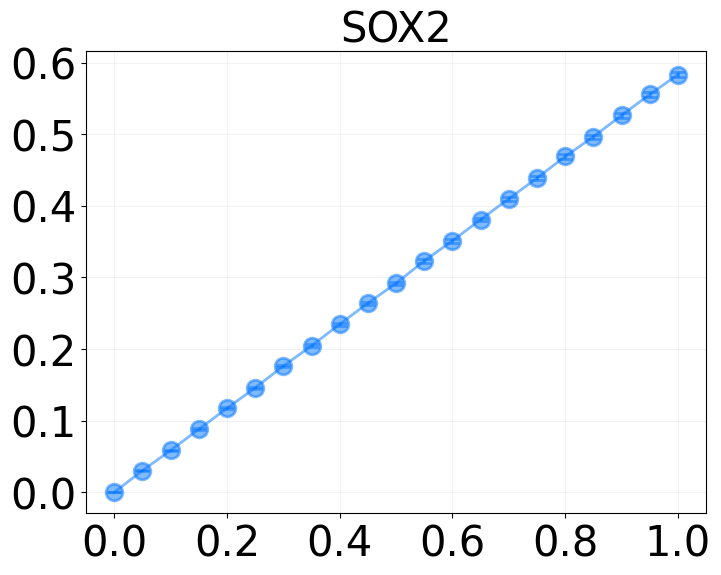

In [42]:
# SOX2
simulate_response_from_lqm_up(
    x_node="EWSR1_FLI1",  
    y_node="SOX2", 
    steps=21,        
    y_initial_prob=0  
)

    x_prob   y_prob   y_error
0     0.00  1.00000  0.000000
1     0.05  0.96966  0.001942
2     0.10  0.94148  0.002720
3     0.15  0.91194  0.003252
4     0.20  0.88272  0.003692
5     0.25  0.85410  0.004049
6     0.30  0.82372  0.004336
7     0.35  0.79546  0.004600
8     0.40  0.76528  0.004803
9     0.45  0.73590  0.004984
10    0.50  0.70818  0.005119
11    0.55  0.67688  0.005234
12    0.60  0.64882  0.005327
13    0.65  0.61922  0.005376
14    0.70  0.59018  0.005407
15    0.75  0.56132  0.005407
16    0.80  0.53112  0.005370
17    0.85  0.50356  0.005313
18    0.90  0.47370  0.005211
19    0.95  0.44458  0.005072
20    1.00  0.41686  0.004888


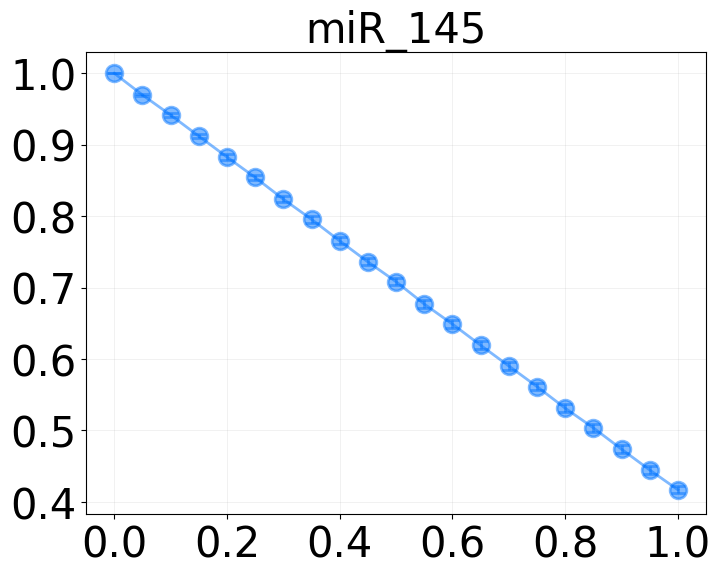

In [43]:
# miR-145
simulate_response_from_lqm_dn(
    x_node="EWSR1_FLI1",  
    y_node="miR_145",  
    steps=21,         
    y_initial_prob=1  
)

    x_prob  y_prob  y_error
0     0.00       0      0.0
1     0.05       0      0.0
2     0.10       0      0.0
3     0.15       0      0.0
4     0.20       0      0.0
5     0.25       0      0.0
6     0.30       0      0.0
7     0.35       0      0.0
8     0.40       0      0.0
9     0.45       0      0.0
10    0.50       0      0.0
11    0.55       0      0.0
12    0.60       0      0.0
13    0.65       0      0.0
14    0.70       0      0.0
15    0.75       0      0.0
16    0.80       0      0.0
17    0.85       0      0.0
18    0.90       0      0.0
19    0.95       0      0.0
20    1.00       0      0.0


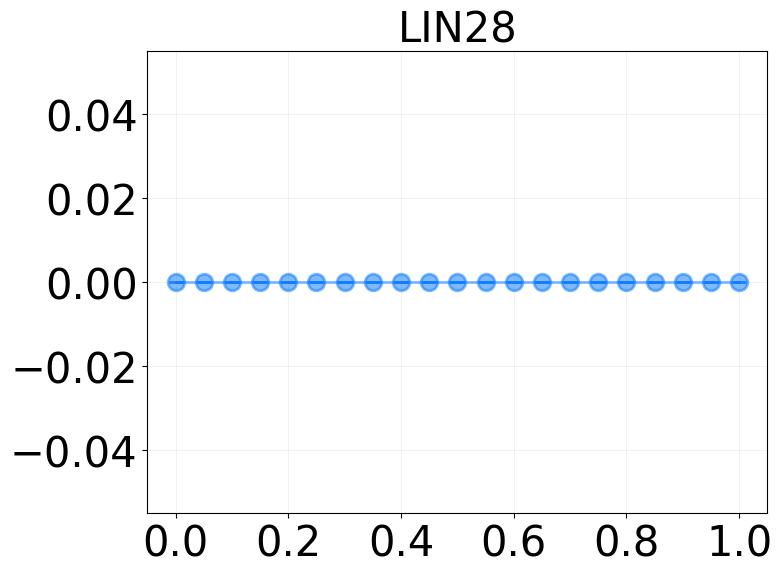

In [44]:
# LIN28
simulate_response_from_lqm_up(
    x_node="EWSR1_FLI1",  
    y_node="LIN28",  
    steps=21,         
    y_initial_prob=0  
)

#### Undifferentiated states

In [45]:
# Set initial states (Undifferentiated states)
#maboss_model.network.set_istate('EWSR1_FLI1', [0, 1])
maboss_model.network.set_istate('miR_145', [1, 0])
maboss_model.network.set_istate('OCT4', [0, 1])
maboss_model.network.set_istate('SOX2', [0, 1])
maboss_model.network.set_istate('c_Myc', [0, 1])
maboss_model.network.set_istate('Let_7', [1, 0])
maboss_model.network.set_istate('STAT3', [0, 1])
maboss_model.network.set_istate('LIN28', [0, 1])
maboss_model.network.set_istate(['Stem_b1', 'Stem_b2'],  {(0,0):0, (0,1):0, (1,0):0, (1,1):1})

Warning, node Stem_b1 was previously bound to othernodes


In [46]:
# Maboss parameters
maboss_model.update_parameters(discrete_time=0, use_physrandgen=0,
        seed_pseudorandom=100, sample_count=50000,
        max_time=15, time_tick=0.5, thread_count=4,
        statdist_traj_count=100, statdist_cluster_threshold=0.9)

    x_prob   y_prob   y_error
0     0.00  0.75012  0.005303
1     0.05  0.76250  0.005504
2     0.10  0.77506  0.005654
3     0.15  0.78758  0.005763
4     0.20  0.80018  0.005828
5     0.25  0.81268  0.005859
6     0.30  0.82488  0.005860
7     0.35  0.83724  0.005830
8     0.40  0.84980  0.005772
9     0.45  0.86226  0.005685
10    0.50  0.87520  0.005564
11    0.55  0.88760  0.005409
12    0.60  0.90020  0.005218
13    0.65  0.91254  0.004988
14    0.70  0.92510  0.004711
15    0.75  0.93770  0.004384
16    0.80  0.95016  0.003995
17    0.85  0.96268  0.003522
18    0.90  0.97528  0.002917
19    0.95  0.98766  0.002093
20    1.00  1.00000  0.000000


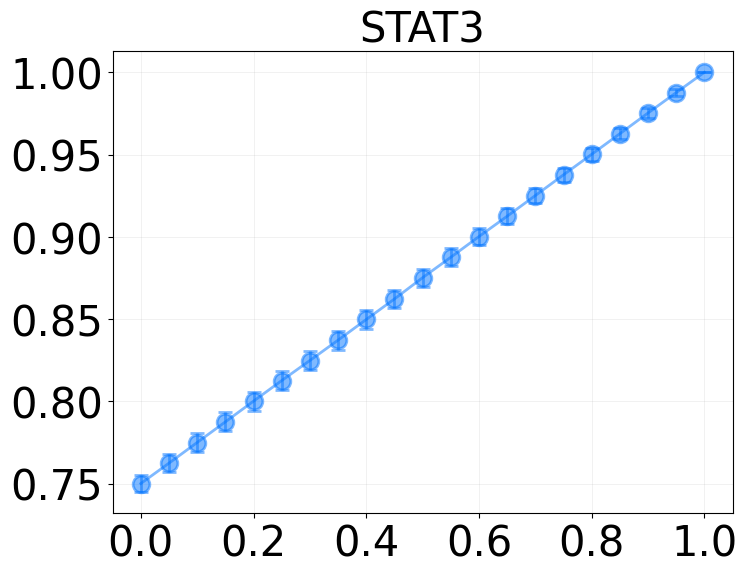

In [47]:
# STAT3
simulate_response_from_lqm_up(
    x_node="EWSR1_FLI1",  
    y_node="STAT3",  
    steps=21,         
    y_initial_prob=1  
)

    x_prob   y_prob   y_error
0     0.00  0.24988  0.000969
1     0.05  0.23750  0.000942
2     0.10  0.22494  0.000919
3     0.15  0.21242  0.000893
4     0.20  0.19982  0.000867
5     0.25  0.18732  0.000837
6     0.30  0.17512  0.000808
7     0.35  0.16276  0.000775
8     0.40  0.15020  0.000743
9     0.45  0.13774  0.000717
10    0.50  0.12480  0.000677
11    0.55  0.11240  0.000649
12    0.60  0.09980  0.000616
13    0.65  0.08746  0.000577
14    0.70  0.07490  0.000530
15    0.75  0.06230  0.000476
16    0.80  0.04984  0.000421
17    0.85  0.03732  0.000362
18    0.90  0.02472  0.000282
19    0.95  0.01234  0.000204
20    1.00  0.00000  0.000000


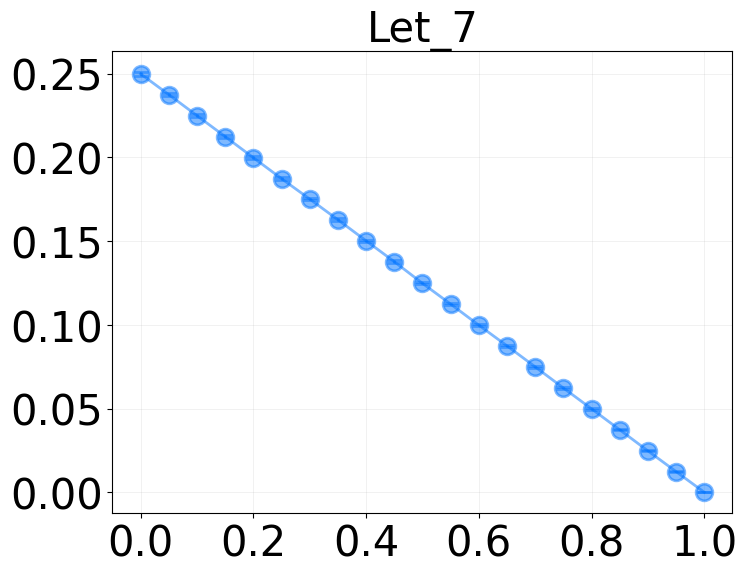

In [48]:
# Let-7
simulate_response_from_lqm_dn(
    x_node="EWSR1_FLI1",  
    y_node="Let_7",  
    steps=21,         
    y_initial_prob=0  
)

    x_prob   y_prob   y_error
0     0.00  0.75012  0.003011
1     0.05  0.76250  0.003262
2     0.10  0.77506  0.003464
3     0.15  0.78758  0.003624
4     0.20  0.80018  0.003748
5     0.25  0.81268  0.003841
6     0.30  0.82488  0.003903
7     0.35  0.83724  0.003939
8     0.40  0.84980  0.003948
9     0.45  0.86226  0.003929
10    0.50  0.87520  0.003884
11    0.55  0.88760  0.003809
12    0.60  0.90020  0.003706
13    0.65  0.91254  0.003571
14    0.70  0.92510  0.003398
15    0.75  0.93770  0.003185
16    0.80  0.95016  0.002920
17    0.85  0.96268  0.002591
18    0.90  0.97528  0.002162
19    0.95  0.98766  0.001560
20    1.00  1.00000  0.000000


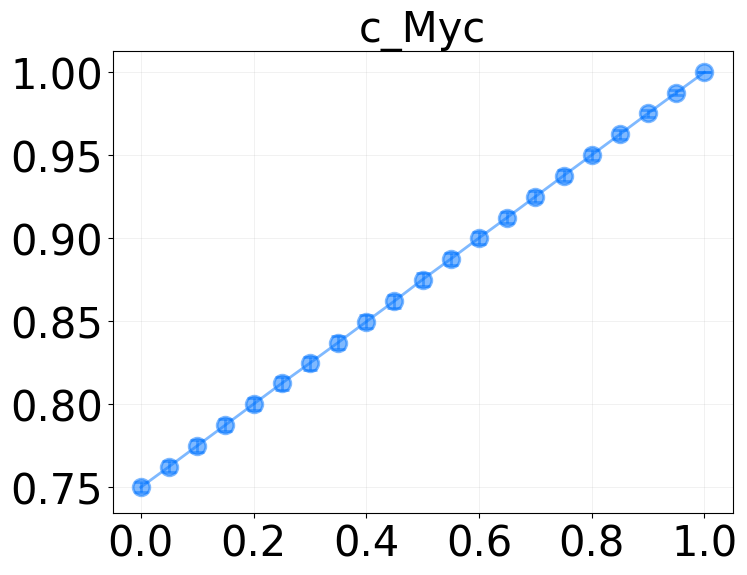

In [49]:
# c_Myc
simulate_response_from_lqm_up(
    x_node="EWSR1_FLI1",  
    y_node="c_Myc",  
    steps=21,         
    y_initial_prob=1  
)